# Mean Grid Activity Distribution Across Trial Labels

This notebook computes the **mean grid activity per trial** from precomputed grid arrays,
joins each trial with metadata labels, and visualises label-wise distributions for each mouse.

**For each mouse:**
- Histogram of mean grid activity by label (overlapping, semi-transparent)
- Boxplot of mean grid activity by label with Holm-corrected significance markers

In [1]:
import importlib
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Make scripts/utils.py importable
SCRIPTS_DIR = Path("../scripts").resolve()
if str(SCRIPTS_DIR) not in sys.path:
    sys.path.insert(0, str(SCRIPTS_DIR))

import utils as utils_module
utils_module = importlib.reload(utils_module)

_short_mouse_name = utils_module._short_mouse_name
load_labelled_grid_paths = utils_module.load_labelled_grid_paths

In [2]:
# -- Configuration ------------------------------------------------------------
ROOT_PATH = Path(
    "/orfeo/scratch/area/ygardinazzi/sensorium_2026/derivatives/"
    "grid-15x15x10_norm-by_minmax"
)
META_ROOT = Path("/u/mdmc/anaflom/projects_mdmc/sensorium/metadata")
GRID_SUBDIR = "trials_grid"

# Discover all mouse directories automatically
MICE = sorted(
    d.name for d in ROOT_PATH.iterdir()
    if d.is_dir() and d.name.startswith("dynamic")
)
print(f"Found {len(MICE)} mice:")
for m in MICE:
    print(f"  {m}")

Found 10 mice:
  dynamic29156-11-10-Video-8744edeac3b4d1ce16b680916b5267ce
  dynamic29228-2-10-Video-8744edeac3b4d1ce16b680916b5267ce
  dynamic29234-6-9-Video-8744edeac3b4d1ce16b680916b5267ce
  dynamic29513-3-5-Video-8744edeac3b4d1ce16b680916b5267ce
  dynamic29514-2-9-Video-8744edeac3b4d1ce16b680916b5267ce
  dynamic29515-10-12-Video-9b4f6a1a067fe51e15306b9628efea20
  dynamic29623-4-9-Video-9b4f6a1a067fe51e15306b9628efea20
  dynamic29647-19-8-Video-9b4f6a1a067fe51e15306b9628efea20
  dynamic29712-5-9-Video-9b4f6a1a067fe51e15306b9628efea20
  dynamic29755-2-8-Video-9b4f6a1a067fe51e15306b9628efea20


In [3]:
def load_mean_grid_activity_df(mouse_id: str) -> pd.DataFrame:
    """Load per-trial mean grid activity and join with labels.

    Returns columns: trial_id, mean_grid_activity, label.
    Mean activity is computed over valid frames only.
    """
    grid_paths, labels, trial_ids, valid_frames = load_labelled_grid_paths(
        ROOT_PATH,
        META_ROOT,
        mouse_id,
        grid_subdir=GRID_SUBDIR,
    )

    if len(grid_paths) == 0:
        print(f"[{mouse_id}] No grid paths found in {GRID_SUBDIR}.")
        return pd.DataFrame(columns=["trial_id", "mean_grid_activity", "label"])

    rows = []
    for gpath, trial_id, label, vf in zip(grid_paths, trial_ids, labels, valid_frames):
        try:
            arr = np.load(gpath, mmap_mode="r")
            if arr.ndim != 4:
                print(f"[{mouse_id}] Warning: unexpected grid shape {arr.shape} in {gpath.name} - skipping.")
                continue

            t_eff = int(min(int(vf), int(arr.shape[3])))
            if t_eff <= 0:
                continue

            mean_val = float(arr[:, :, :, :t_eff].mean())
            rows.append({
                "trial_id": int(trial_id),
                "mean_grid_activity": mean_val,
                "label": str(label),
            })
        except Exception as exc:
            print(f"[{mouse_id}] Warning: failed loading {gpath.name}: {exc}")

    return pd.DataFrame(rows)

## Per-Mouse Statistical Analysis

All inferential analyses below are run **separately for each mouse** using:

- OLS model: `mean_grid_activity ~ C(label)`
- Multiple comparisons between labels **within each mouse**
  (Holm-corrected pairwise contrasts, with Tukey fallback)

In [4]:
import statsmodels.formula.api as smf
from statsmodels.stats.multicomp import pairwise_tukeyhsd

if "labels_order" not in globals():
    labels_order = [
        "NaturalVideo",
        "NaturalImages",
        "PinkNoise",
        "RandomDots",
        "GaussianDot",
        "Gabor",
    ]

# Build per-mouse datasets once
per_mouse_data = {}
for mouse_id in MICE:
    df_mouse = load_mean_grid_activity_df(mouse_id)
    if df_mouse.empty:
        continue

    df_mouse = df_mouse.copy()
    df_mouse["mouse"] = _short_mouse_name(mouse_id)

    present_labels = list(df_mouse["label"].dropna().unique())
    ordered_labels = [label for label in labels_order if label in present_labels]
    extra_labels = sorted(label for label in present_labels if label not in labels_order)
    label_levels = ordered_labels + extra_labels
    df_mouse["label"] = pd.Categorical(df_mouse["label"], categories=label_levels, ordered=True)

    per_mouse_data[df_mouse["mouse"].iloc[0]] = df_mouse[["trial_id", "label", "mean_grid_activity"]].reset_index(drop=True)

if not per_mouse_data:
    raise RuntimeError("No per-mouse mean-grid-activity rows available.")

print(f"Per-mouse datasets available: {len(per_mouse_data)}")
for mouse_name, df_mouse in per_mouse_data.items():
    n_labels = df_mouse["label"].nunique()
    print(f"  {mouse_name}: n={len(df_mouse)}, labels={n_labels}")

print("=== Per-mouse OLS and pairwise label contrasts ===")
ols_results = {}
pairwise_results = {}

for mouse_name, df_mouse in per_mouse_data.items():
    n_labels = df_mouse["label"].nunique()
    if n_labels < 2:
        print(f"\n[{mouse_name}] skipped (needs at least 2 labels)")
        continue

    print(f"\n[{mouse_name}] OLS: mean_grid_activity ~ C(label)")
    print(f"Rows={len(df_mouse)}, Labels={n_labels}")

    ols_model = smf.ols("mean_grid_activity ~ C(label)", data=df_mouse)
    ols_result = ols_model.fit()
    ols_results[mouse_name] = ols_result

    display(ols_result.summary())

    coef_table = ols_result.params.rename("coef").to_frame()
    ci_ols = ols_result.conf_int()
    coef_table["ci_low"] = ci_ols.loc[coef_table.index, 0]
    coef_table["ci_high"] = ci_ols.loc[coef_table.index, 1]
    print("OLS coefficients (95% CI):")
    display(coef_table)

    print("Pairwise label comparisons (within mouse, Holm correction):")
    try:
        ph = ols_result.t_test_pairwise("C(label)", method="holm")
        pairwise_results[mouse_name] = ph.result_frame
        display(ph.result_frame)
    except Exception as exc:
        print(f"Model-based pairwise contrasts unavailable ({exc}). Falling back to Tukey HSD.")
        tukey = pairwise_tukeyhsd(
            endog=df_mouse["mean_grid_activity"],
            groups=df_mouse["label"],
            alpha=0.05,
        )
        tukey_df = pd.DataFrame(
            tukey._results_table.data[1:],
            columns=tukey._results_table.data[0],
        )
        pairwise_results[mouse_name] = tukey_df
        display(tukey_df)

Per-mouse datasets available: 10
  rec-29156-11-10: n=720, labels=4
  rec-29228-2-10: n=704, labels=4
  rec-29234-6-9: n=729, labels=4
  rec-29513-3-5: n=713, labels=4
  rec-29514-2-9: n=723, labels=4
  rec-29515-10-12: n=406, labels=1
  rec-29623-4-9: n=385, labels=1
  rec-29647-19-8: n=414, labels=1
  rec-29712-5-9: n=419, labels=1
  rec-29755-2-8: n=413, labels=1
=== Per-mouse OLS and pairwise label contrasts ===

[rec-29156-11-10] OLS: mean_grid_activity ~ C(label)
Rows=720, Labels=4


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:     mean_grid_activity   R-squared:                       0.272
Model:                            OLS   Adj. R-squared:                  0.269
Method:                 Least Squares   F-statistic:                     89.14
Date:                Tue, 05 May 2026   Prob (F-statistic):           5.07e-49
Time:                        10:31:00   Log-Likelihood:                 3308.6
No. Observations:                 720   AIC:                            -6609.
Df Residuals:                     716   BIC:                            -6591.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
===========================================================================================
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                   0.0210      0.000    196.070      0.000       0.021       0.021
C(label)[T.PinkNoise]      -0.0027      0.000     -8.155      0.000      -0.003      -0.002
C(label)[T.RandomDots]      0.0018      0.000      6.213      0.000       0.001       0.002
C(label)[T.GaussianDot]    -0.0041      0.000    -12.154      0.000      -0.005      -0.003
==============================================================================
Omnibus:                      130.464   Durbin-Watson:                   1.446
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              256.764
Skew:                           1.036   Prob(JB):                     1.76e-56
Kurtosis:                       5.065   Cond. No.                         4.06
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

OLS coefficients (95% CI):


,coef,ci_low,ci_high
Intercept,0.021010,0.020799,0.021220
C(label)[T.PinkNoise],-0.002745,-0.003405,-0.002084
C(label)[T.RandomDots],0.001838,0.001257,0.002419
C(label)[T.GaussianDot],-0.004090,-0.004751,-0.003430


Pairwise label comparisons (within mouse, Holm correction):


...

OLS coefficients (95% CI):


,coef,ci_low,ci_high
Intercept,0.017032,0.016708,0.017357
C(label)[T.RandomDots],0.003237,0.002338,0.004137
C(label)[T.GaussianDot],-0.004164,-0.005196,-0.003133
C(label)[T.Gabor],-0.004569,-0.005601,-0.003538


Pairwise label comparisons (within mouse, Holm correction):


,coef,std err,t,P>|t|,Conf. Int. Low,Conf. Int. Upp.,pvalue-holm,reject-holm
RandomDots-NaturalVideo,0.003237,0.000458,7.063745,3.833297e-12,0.002338,0.004137,7.666594e-12,True
GaussianDot-NaturalVideo,-0.004164,0.000526,-7.923665,8.783045e-15,-0.005196,-0.003133,2.634913e-14,True
Gabor-NaturalVideo,-0.004569,0.000526,-8.694505,2.346535e-17,-0.005601,-0.003538,9.386139e-17,True
GaussianDot-RandomDots,-0.007402,0.000657,-11.266808,3.142182e-27,-0.008692,-0.006112,1.571091e-26,True
Gabor-RandomDots,-0.007807,0.000657,-11.883473,7.332192e-30,-0.009097,-0.006517,4.399315e-29,True
Gabor-GaussianDot,-0.000405,0.000706,-0.574224,5.659960e-01,-0.001790,0.000980,5.659960e-01,False



[rec-29515-10-12] skipped (needs at least 2 labels)

[rec-29623-4-9] skipped (needs at least 2 labels)

[rec-29647-19-8] skipped (needs at least 2 labels)

[rec-29712-5-9] skipped (needs at least 2 labels)

[rec-29755-2-8] skipped (needs at least 2 labels)


In [5]:
# Aggregate per-mouse statistical results into tidy DataFrames
from pathlib import Path

# OLS coefficients
ols_rows = []
for mouse_name, res in ols_results.items():
    ci_o = res.conf_int()
    for term, coef in res.params.items():
        ols_rows.append({
            "mouse": mouse_name,
            "model": "OLS",
            "result_type": "coefficient",
            "term": term,
            "coef": float(coef),
            "ci_low": float(ci_o.loc[term, 0]),
            "ci_high": float(ci_o.loc[term, 1]),
            "p_value": float(res.pvalues.get(term, float("nan"))),
        })

df_ols_agg = pd.DataFrame(ols_rows)

# Within-mouse pairwise comparisons
pairwise_rows = []
for mouse_name, df_pw in pairwise_results.items():
    df_local = df_pw.copy()
    df_local = df_local.rename(
        columns={
            "pvalue-holm": "p_value_adj_holm",
            "reject-holm": "reject_holm",
            "P>|t|": "p_value",
            "Conf. Int. Low": "ci_low",
            "Conf. Int. Upp.": "ci_high",
        }
    )
    df_local = df_local.reset_index().rename(columns={"index": "comparison"})
    df_local["mouse"] = mouse_name
    df_local["model"] = "OLS"
    df_local["result_type"] = "pairwise_label_comparison"
    pairwise_rows.append(df_local)

df_pairwise_agg = pd.concat(pairwise_rows, ignore_index=True) if pairwise_rows else pd.DataFrame()

# Unified aggregated table
df_stats_agg = pd.concat([
    df_ols_agg,
    df_pairwise_agg,
], ignore_index=True, sort=False)

print("Aggregated shapes:")
print(f"  OLS coefficients:      {df_ols_agg.shape}")
print(f"  Pairwise contrasts:    {df_pairwise_agg.shape}")
print(f"  Unified table:         {df_stats_agg.shape}")

display(df_stats_agg.head(20))

# Optional export
EXPORT_CSV = False
if EXPORT_CSV:
    out_csv = Path("../results/grid_activity_stats_per_mouse_aggregated.csv").resolve()
    out_csv.parent.mkdir(parents=True, exist_ok=True)
    df_stats_agg.to_csv(out_csv, index=False)
    print(f"Saved: {out_csv}")

Aggregated shapes:
  OLS coefficients:      (20, 8)
  Pairwise contrasts:    (30, 12)
  Unified table:         (50, 13)


,mouse,model,result_type,term,coef,ci_low,ci_high,p_value,comparison,std err,t,p_value_adj_holm,reject_holm
0,rec-29156-11-10,OLS,coefficient,Intercept,0.021010,0.020799,0.021220,0.000000e+00,NaN,NaN,NaN,NaN,NaN
1,rec-29156-11-10,OLS,coefficient,C(label)[T.PinkNoise],-0.002745,-0.003405,-0.002084,1.559631e-15,NaN,NaN,NaN,NaN,NaN
2,rec-29156-11-10,OLS,coefficient,C(label)[T.RandomDots],0.001838,0.001257,0.002419,8.790035e-10,NaN,NaN,NaN,NaN,NaN
3,rec-29156-11-10,OLS,coefficient,C(label)[T.GaussianDot],-0.004090,-0.004751,-0.003430,4.922036e-31,NaN,NaN,NaN,NaN,NaN
4,rec-29228-2-10,OLS,coefficient,Intercept,0.019807,0.019524,0.020089,0.000000e+00,NaN,NaN,NaN,NaN,NaN
5,rec-29228-2-10,OLS,coefficient,C(label)[T.NaturalImages],-0.002292,-0.003183,-0.001402,5.531410e-07,NaN,NaN,NaN,NaN,NaN
6,rec-29228-2-10,OLS,coefficient,C(label)[T.PinkNoise],-0.005156,-0.006047,-0.004266,1.348974e-27,NaN,NaN,NaN,NaN,NaN
7,rec-29228-2-10,OLS,coefficient,C(label)[T.Gabor],-0.007033,-0.007924,-0.006143,7.864605e-47,NaN,NaN,NaN,NaN,NaN
8,rec-29234-6-9,OLS,coefficient,Intercept,0.021138,0.020820,0.021457,0.000000e+00,NaN,NaN,NaN,NaN,NaN
9,rec-29234-6-9,OLS,coefficient,C(label)[T.NaturalImages],-0.003447,-0.004446,-0.002447,2.685766e-11,NaN,NaN,NaN,NaN,NaN


In [6]:
# Compact per-mouse summary tables from aggregated results
if "df_stats_agg" not in globals():
    raise RuntimeError("df_stats_agg is missing. Run the aggregation cell first.")

# OLS coefficient summary (per mouse x term)
coef_summary = (
    df_stats_agg[df_stats_agg["result_type"].isin(["fixed_effect", "coefficient"])]
    .pivot_table(
        index=["mouse", "term"],
        columns=["model", "result_type"],
        values=["coef", "p_value"],
        aggfunc="first",
    )
    .sort_index()
    .round(6)
)

# Pairwise comparison compact summary
pairwise_summary = (
    df_stats_agg[df_stats_agg["result_type"] == "pairwise_label_comparison"]
    .loc[:, ["mouse", "comparison", "coef", "p_value", "p_value_adj_holm", "reject_holm"]]
    .sort_values(["mouse", "comparison"])
    .reset_index(drop=True)
    .round(6)
)

print("Coefficient summary shape:", coef_summary.shape)
display(coef_summary)

print("\nPairwise summary shape:", pairwise_summary.shape)
display(pairwise_summary.head(50))

# Optional exports
EXPORT_SUMMARY_CSV = False
if EXPORT_SUMMARY_CSV:
    out_dir = Path("../results").resolve()
    out_dir.mkdir(parents=True, exist_ok=True)
    coef_path = out_dir / "grid_activity_stats_per_mouse_coef_summary.csv"
    pairwise_path = out_dir / "grid_activity_stats_per_mouse_pairwise_summary.csv"
    coef_summary.reset_index().to_csv(coef_path, index=False)
    pairwise_summary.to_csv(pairwise_path, index=False)
    print(f"Saved: {coef_path}")
    print(f"Saved: {pairwise_path}")

Coefficient summary shape: (20, 2)


coef     p_value
model                                             OLS         OLS
result_type                               coefficient coefficient
mouse           term                                             
rec-29156-11-10 C(label)[T.GaussianDot]     -0.004090    0.000000
                C(label)[T.PinkNoise]       -0.002745    0.000000
                C(label)[T.RandomDots]       0.001838    0.000000
                Intercept                    0.021010    0.000000
rec-29228-2-10  C(label)[T.Gabor]           -0.007033    0.000000
                C(label)[T.NaturalImages]   -0.002292    0.000001
                C(label)[T.PinkNoise]       -0.005156    0.000000
                Intercept                    0.019807    0.000000
rec-29234-6-9   C(label)[T.Gabor]           -0.005325    0.000000
                C(label)[T.NaturalImages]   -0.003447    0.000000
                C(label)[T.RandomDots]       0.003568    0.000000
                Intercept                    0.021138    0.000000
rec-29513-3-5   C(label)[T.GaussianDot]     -0.004995    0.000000
                C(label)[T.NaturalImages]   -0.003271    0.000000
                C(label)[T.PinkNoise]       -0.003410    0.000000
                Intercept                    0.019331    0.000000
rec-29514-2-9   C(label)[T.Gabor]           -0.004569    0.000000
                C(label)[T.GaussianDot]     -0.004164    0.000000
                C(label)[T.RandomDots]       0.003237    0.000000
                Intercept                    0.017032    0.000000


Pairwise summary shape: (30, 6)


,mouse,comparison,coef,p_value,p_value_adj_holm,reject_holm
0,rec-29156-11-10,GaussianDot-NaturalVideo,-0.004090,0.000000,0.000000,True
1,rec-29156-11-10,GaussianDot-PinkNoise,-0.001346,0.002954,0.002954,True
2,rec-29156-11-10,GaussianDot-RandomDots,-0.005928,0.000000,0.000000,True
3,rec-29156-11-10,PinkNoise-NaturalVideo,-0.002745,0.000000,0.000000,True
4,rec-29156-11-10,RandomDots-NaturalVideo,0.001838,0.000000,0.000000,True
5,rec-29156-11-10,RandomDots-PinkNoise,0.004583,0.000000,0.000000,True
6,rec-29228-2-10,Gabor-NaturalImages,-0.004741,0.000000,0.000000,True
7,rec-29228-2-10,Gabor-NaturalVideo,-0.007033,0.000000,0.000000,True
8,rec-29228-2-10,Gabor-PinkNoise,-0.001877,0.002112,0.002112,True
9,rec-29228-2-10,NaturalImages-NaturalVideo,-0.002292,0.000001,0.000002,True


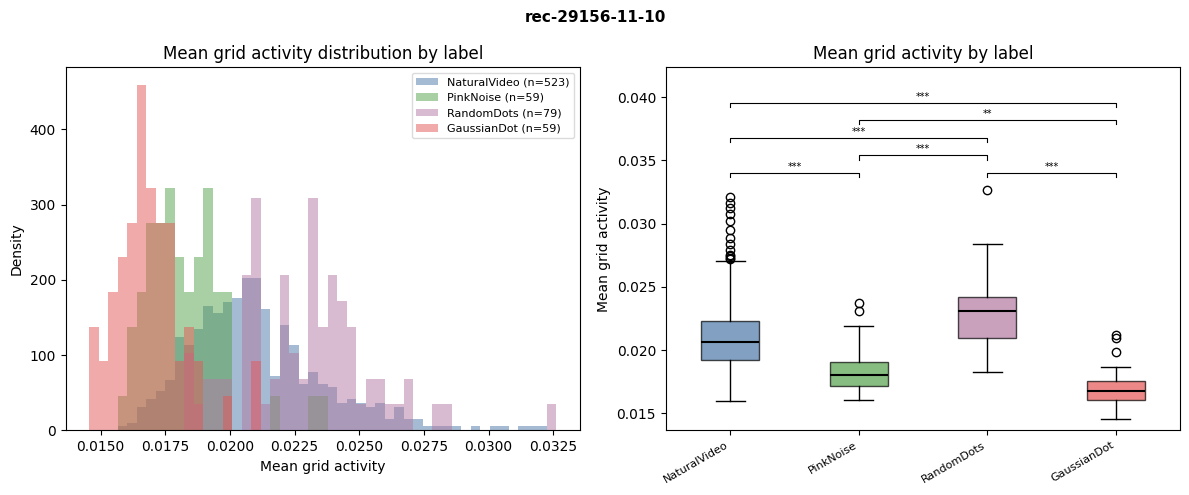

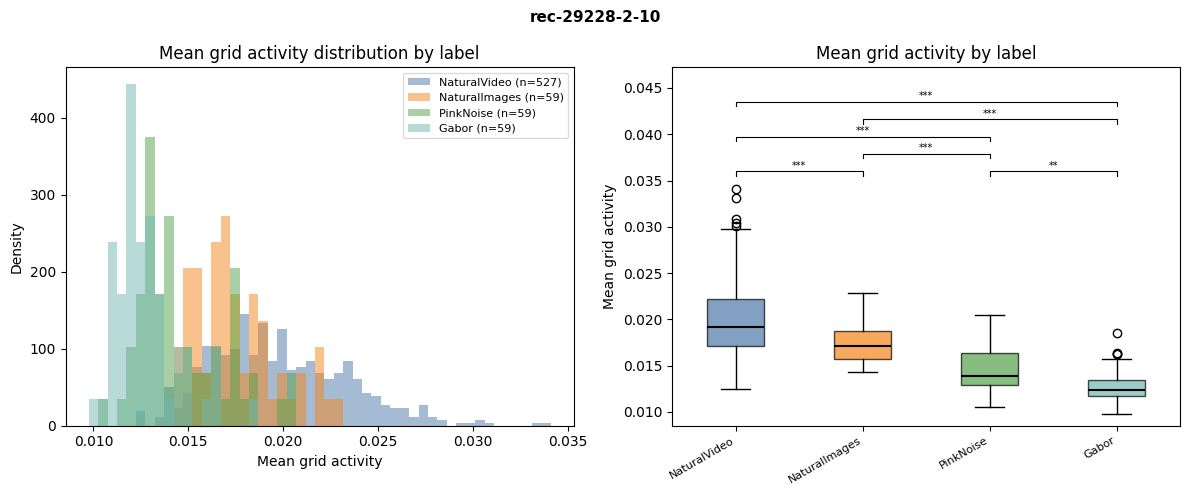

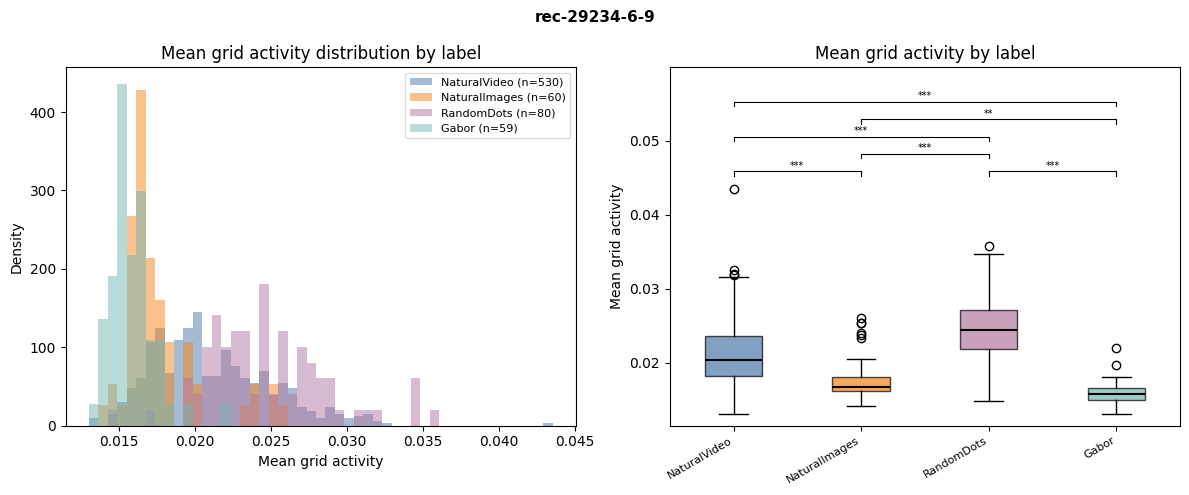

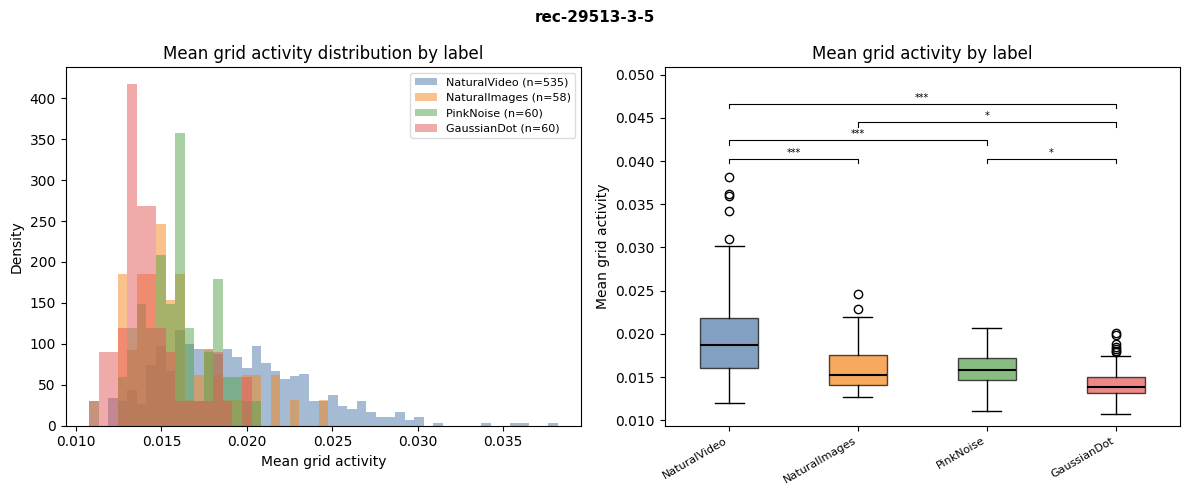

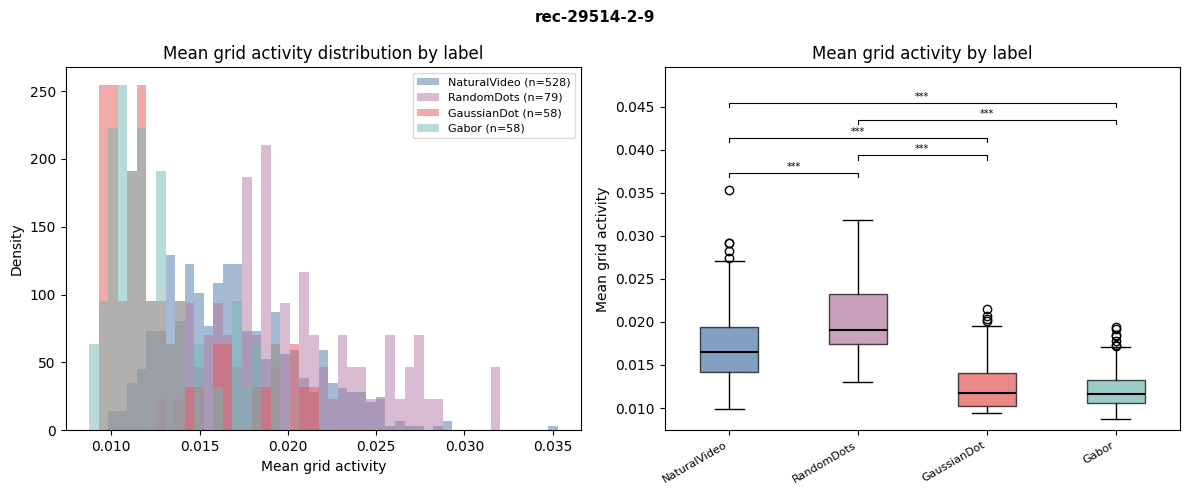

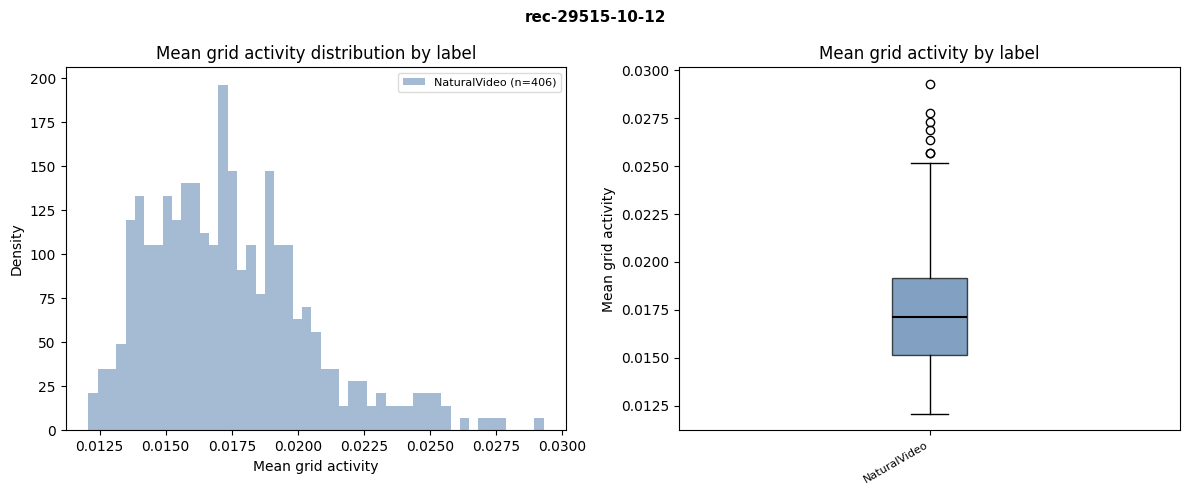

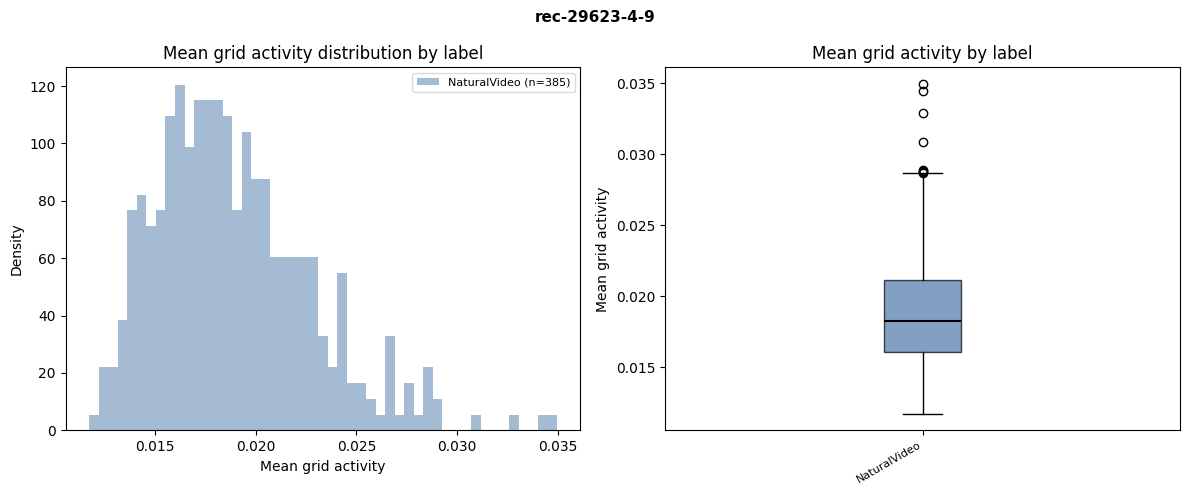

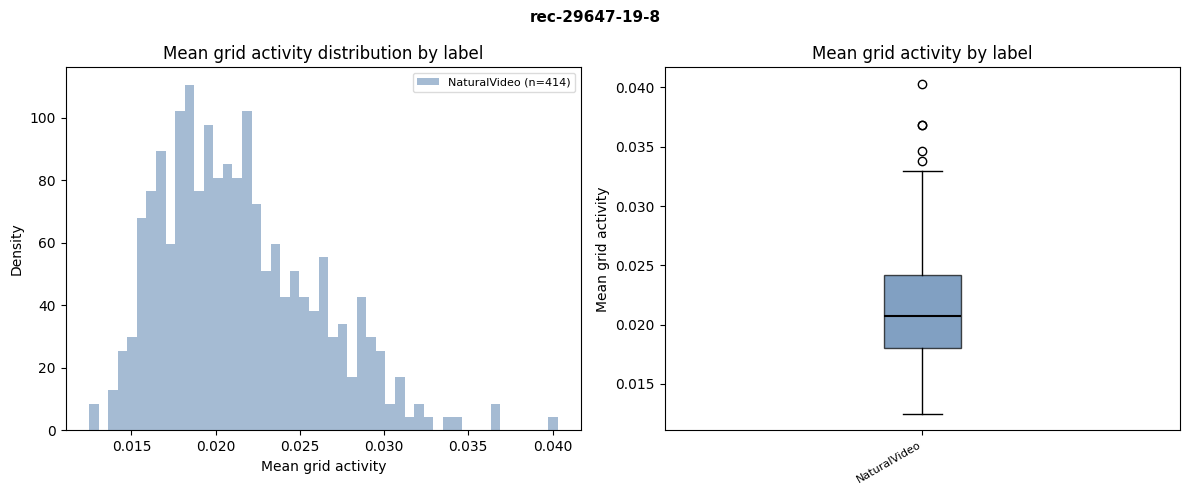

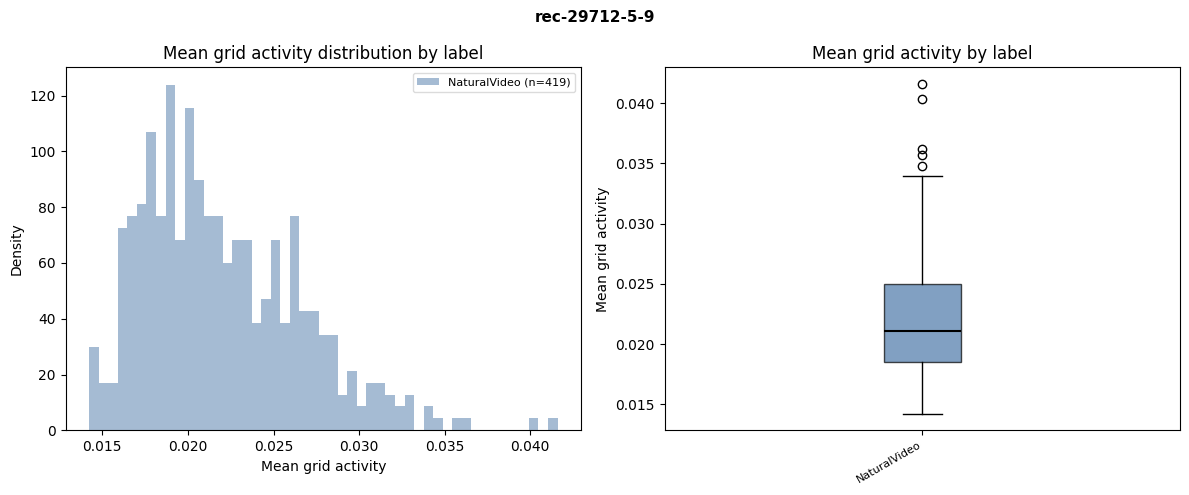

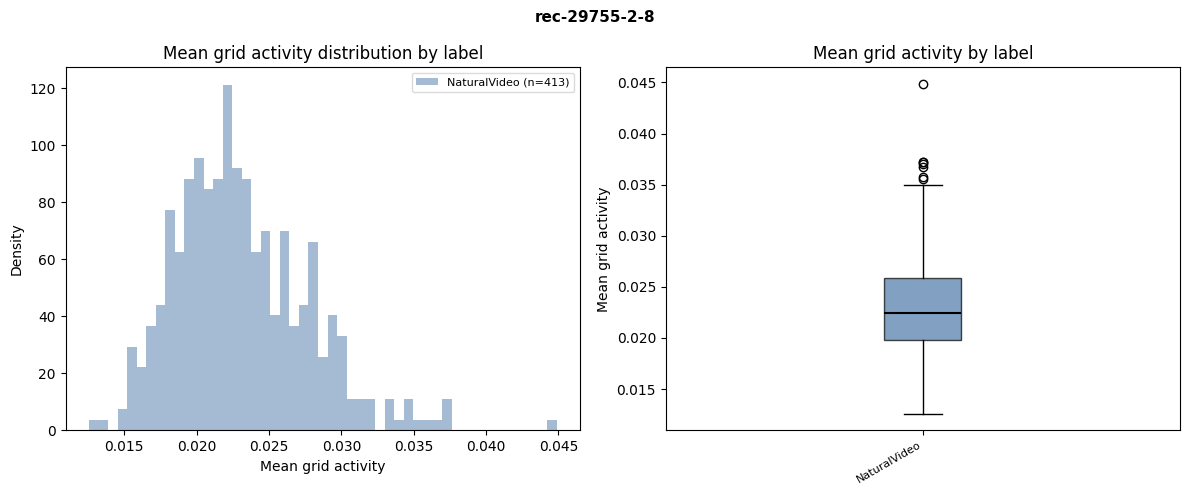

In [7]:
# -- Plot mean-grid-activity distributions for every mouse ---------------------
figures_folder = Path("figures").resolve()
figures_folder.mkdir(parents=True, exist_ok=True)

def _get_sig_stars(p_val):
    if p_val < 0.001:
        return "***"
    if p_val < 0.01:
        return "**"
    if p_val < 0.05:
        return "*"
    return None


def _parse_comparison(comp_str, label_set):
    for i in range(1, len(comp_str)):
        if comp_str[i] == "-":
            a, b = comp_str[:i], comp_str[i + 1:]
            if a in label_set and b in label_set:
                return a, b
    return None, None


def _assign_bracket_levels(pairs_positions):
    used = []  # (level, x_min, x_max)
    levels = []
    for x1, x2 in pairs_positions:
        xlo, xhi = min(x1, x2), max(x1, x2)
        level = 0
        while any(lvl == level and not (xhi < lo or xlo > hi) for lvl, lo, hi in used):
            level += 1
        used.append((level, xlo, xhi))
        levels.append(level)
    return levels


_labels_order = ["NaturalVideo", "NaturalImages", "PinkNoise", "RandomDots", "GaussianDot", "Gabor"]
_label_colours = {
    "NaturalVideo": "#4C78A8",
    "NaturalImages": "#F58518",
    "PinkNoise": "#54A24B",
    "RandomDots": "#B279A2",
    "GaussianDot": "#E45756",
    "Gabor": "#72B7B2",
}

for mouse_id in MICE:
    df = load_mean_grid_activity_df(mouse_id)
    mouse_name = _short_mouse_name(mouse_id)

    if df.empty:
        print(f"[{mouse_id}] No data - skipping.")
        continue

    present_labels = list(df["label"].dropna().unique())
    ordered_labels = [lbl for lbl in _labels_order if lbl in present_labels]
    extra_labels = sorted(lbl for lbl in present_labels if lbl not in _labels_order)
    labels = ordered_labels + extra_labels
    n_labels = len(labels)
    label_set = set(labels)
    label_pos = {lbl: i + 1 for i, lbl in enumerate(labels)}

    fallback_cmap = plt.get_cmap("tab10")
    colours = {lbl: _label_colours.get(lbl, fallback_cmap(i % 10)) for i, lbl in enumerate(labels)}

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    fig.suptitle(mouse_name, fontsize=11, fontweight="bold")

    # Left: overlapping histograms
    ax_hist = axes[0]
    all_vals = df["mean_grid_activity"].values
    bins = np.linspace(all_vals.min(), all_vals.max(), 50)

    for lbl in labels:
        vals = df.loc[df["label"] == lbl, "mean_grid_activity"].values
        ax_hist.hist(
            vals,
            bins=bins,
            alpha=0.5,
            label=f"{lbl} (n={len(vals)})",
            color=colours[lbl],
            edgecolor="none",
            density=True,
        )

    ax_hist.set_xlabel("Mean grid activity")
    ax_hist.set_ylabel("Density")
    ax_hist.set_title("Mean grid activity distribution by label")
    ax_hist.legend(fontsize=8, framealpha=0.7)

    # Right: boxplot
    ax_box = axes[1]
    group_data = [df.loc[df["label"] == lbl, "mean_grid_activity"].values for lbl in labels]
    bp = ax_box.boxplot(
        group_data,
        patch_artist=True,
        medianprops=dict(color="black", linewidth=1.5),
    )
    for patch, lbl in zip(bp["boxes"], labels):
        patch.set_facecolor(colours[lbl])
        patch.set_alpha(0.7)

    ax_box.set_xticks(range(1, n_labels + 1))
    ax_box.set_xticklabels(labels, rotation=30, ha="right", fontsize=8)
    ax_box.set_ylabel("Mean grid activity")
    ax_box.set_title("Mean grid activity by label")

    # Significance brackets
    if mouse_name in pairwise_results:
        df_pw = pairwise_results[mouse_name]
        sig_pairs = []
        for comp_str in df_pw.index:
            row = df_pw.loc[comp_str]
            if not row.get("reject-holm", False):
                continue
            stars = _get_sig_stars(float(row["pvalue-holm"]))
            if stars is None:
                continue
            lbl_a, lbl_b = _parse_comparison(comp_str, label_set)
            if lbl_a is None or lbl_b is None:
                continue
            x1, x2 = label_pos[lbl_a], label_pos[lbl_b]
            sig_pairs.append((lbl_a, lbl_b, stars, x1, x2))

        if sig_pairs:
            sig_pairs.sort(key=lambda t: abs(t[4] - t[3]))
            levels = _assign_bracket_levels([(t[3], t[4]) for t in sig_pairs])

            y_data_max = max((gd.max() if len(gd) else 0) for gd in group_data)
            y_lo, y_hi = ax_box.get_ylim()
            step = (y_hi - y_lo) * 0.07
            y_base = y_data_max + step

            for (_lbl_a, _lbl_b, stars, x1, x2), level in zip(sig_pairs, levels):
                y = y_base + level * step
                tip = step * 0.25
                ax_box.plot([x1, x1, x2, x2], [y - tip, y, y, y - tip], lw=0.8, color="black")
                ax_box.text((x1 + x2) / 2, y + step * 0.05, stars, ha="center", va="bottom", fontsize=7)

            new_top = y_base + (max(levels) + 1) * step + step
            ax_box.set_ylim(y_lo, max(y_hi, new_top))

    plt.tight_layout()
    plt.savefig(figures_folder / f"mean_grid_activity_distribution_{mouse_name}.png", dpi=300)
    plt.show()